# Fast.ai Unit 1 Mini Project: Image Classifier
This is the central notebook for the Fast.ai Practical Deep Learning course **Unit 1 Mini Project**, which is an image classifier designed to classify paintings based on a small subset of well-known artists. These artists will be primarily taken from the Impressionistic time period.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from fastai.vision.all import * # fastai image classification
!pip install -Uqq duckduckgo_search==5.3.1b1

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Gather data and search for images
For this project we're going to use DuckDuckGo to find some images of Impressionistic paintings. First we'll pull down some sample images of Impressionistic painters, then download larger amounts of images for training the model. 

In [2]:
import time
from duckduckgo_search import DDGS
from fastcore.all import *

def search_images(keywords, max_images=200):
    with DDGS() as ddgs:
        results = list(ddgs.images(keywords, max_results=max_images))
        time.sleep(2)
        return [r['image'] for r in results]

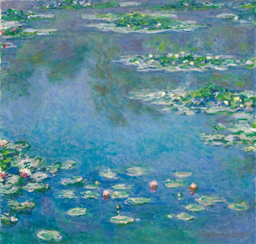

In [3]:
from fastdownload import download_url
from fastai.vision.all import *

# Test to see what kind of results we get when searching for Monet paintings
urls = search_images('monet painting', max_images=1)
urls[0]

dest = 'monet-test-1.jpg'
download_url(urls[0], dest, show_progress=False)

im = Image.open(dest)
im.to_thumb(256,256) # show a preview of the image

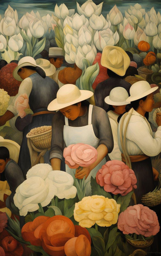

In [9]:
# Do the same thing with a variety of other Impressionistic artists before pulling down mass images to train
urls = search_images('diego rivera painting', max_images=1)
urls[0]

dest1 = 'rivera-test-1.jpg'
download_url(urls[0], dest1, show_progress=False)

im = Image.open(dest1)
im.to_thumb(256,256) # show a preview of the image

In [ ]:
# full list of artists: searches = 'monet', 'renoir', 'rivera', 'degas', 'morisot', 'cassatt', 'cezanne', 'van gogh', 'gauguin', 'manet', 'pissarro', 'seurat', 'toulouse-lautrec', 'whistler', 'turner', 'matisse', 'picasso', 'braque', 'mondrian', 'warhol'

# Pull down photos of paintings of 15-20 artists from Post-Impressionist to Cubist
searches = 'monet', 'renoir', 'rivera', 'degas', 'morisot' # we might have to do only 5 at a time to prevent this from taking forever...
path = Path('painting_data')
path.mkdir(exist_ok = True, parents = True)

for name in searches:
    dest = (path/name)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{name} painting'), timeout=2) # call the search_images function for each artist in the list, getting 200 images for each artist, and downloading them to a folder named after the artist
    time.sleep(3)
    resize_images(path/name, max_size=400, dest=path/name) # start with a 400 x 400 pixels size

# Apparently this ran and did something? (1m 22s)

## Train the model
We will now proceed to train a **restnet34** classifier model and see how it performs on the given data.